# RetailRocket: Funnel Hawkes results

This notebook **reads saved results** from `results/retailrocket/<run_id>/` and produces a compact report: 
- dataset QA summary (optional, if you ran `scripts/qa_retailrocket.py`)
- LL gain diagnostics (overall + split by `purchases_test==0`)
- alpha-by-type distributions
- one example visitor timeline + intensity plot

Prereq: run at least once:
```bash
.venv/bin/python scripts/qa_retailrocket.py --run-id qa-full
.venv/bin/python scripts/run_real.py --path data/raw/retailrocket/events.csv --train-ratio 0.7 --min-events 10 --min-train-events 20 --min-purchases-train 2 --max-seqs 200000
```


In [1]:
import sys
from pathlib import Path
import json

ROOT = Path.cwd().resolve()
for _ in range(6):
    if (ROOT / 'src').is_dir():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


## Select run


In [2]:
RESULTS_DIR = ROOT / 'results' / 'retailrocket'
DATA_PATH = ROOT / 'data' / 'raw' / 'retailrocket' / 'events.csv'

RUN_ID = None  # e.g. 'retailrocket-20260126-183513' (None -> latest)
QA_RUN_ID = None  # e.g. 'qa-full' (None -> latest found)

def _latest_dir_with_file(base, filename, prefix=None):
    cands = []
    for p in base.iterdir():
        if not p.is_dir():
            continue
        if prefix is not None and not p.name.startswith(prefix):
            continue
        f = p / filename
        if f.exists():
            cands.append((f.stat().st_mtime, p))
    cands.sort(reverse=True)
    return cands[0][1] if cands else None

if RUN_ID is None:
    run_dir = _latest_dir_with_file(RESULTS_DIR, 'summary.csv', prefix='retailrocket-')
else:
    run_dir = RESULTS_DIR / RUN_ID

if run_dir is None or not (run_dir / 'summary.csv').exists():
    raise FileNotFoundError('No results found. Run scripts/run_real.py first.')

if QA_RUN_ID is None:
    qa_parent = _latest_dir_with_file(RESULTS_DIR, 'qa/qa_summary.json', prefix='qa-')
    qa_dir = qa_parent / 'qa' if qa_parent is not None else None
else:
    qa_dir = RESULTS_DIR / QA_RUN_ID / 'qa'

print('run_dir:', run_dir)
print('qa_dir :', qa_dir)
print('data   :', DATA_PATH)

HAS_DATA = DATA_PATH.exists()
print('data exists:', HAS_DATA)


run_dir: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260126-183513
qa_dir : None
data   : /Users/amosh239/repo/mkn/Hawk's proccess/data/raw/retailrocket/events.csv
data exists: True


## Dataset QA (optional)


In [3]:
qa_summary = None
grid = None
if qa_dir is not None and (qa_dir / 'qa_summary.json').exists():
    qa_summary = json.loads((qa_dir / 'qa_summary.json').read_text())
    grid = pd.read_csv(qa_dir / 'filter_grid.csv')
    print('QA loaded:', qa_dir)
else:
    print('QA not found (ok). Run scripts/qa_retailrocket.py to generate it.')

qa_summary


QA not found (ok). Run scripts/qa_retailrocket.py to generate it.


In [4]:
if grid is not None:
    pivot = grid.pivot(index='min_events', columns='train_ratio', values='with_test_transaction')
    display(pivot)
    
    plt.figure(figsize=(7,4))
    plt.imshow(pivot.values, aspect='auto')
    plt.title('with_test_transaction')
    plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(i) for i in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, str(int(pivot.values[i,j])), ha='center', va='center', fontsize=8, color='white')
    plt.tight_layout()
    plt.show()


## Experiment results


In [5]:
df = pd.read_csv(run_dir / 'summary.csv')
for c in ['ll_baseline','ll_hawkes','ll_gain','test_hours']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print('rows:', len(df))
print('ll_unit:', df['ll_unit'].unique().tolist() if 'll_unit' in df.columns else None)
print('purchases_test==0:', int((df['purchases_test']==0).sum()) if 'purchases_test' in df.columns else None)
print('purchases_test>0 :', int((df['purchases_test']>0).sum()) if 'purchases_test' in df.columns else None)

df.head()


rows: 78
ll_unit: ['per_hour']
purchases_test==0: 55
purchases_test>0 : 23


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_unit,ll_baseline,ll_hawkes,ll_gain,mu_baseline,mu_hawkes,mu,alpha_type_0,alpha_type_1,alpha_type_2
0,3258,26,23,3,2,0,17.797517,per_hour,-1.046913e-08,-1.046913e-08,-4.310278e-15,1.000000,1.000000,1.000000,0.000000,0.000000,0.0
1,6699,104,79,25,2,2,2.035775,per_hour,-1.812788e+01,-1.812788e+01,1.742074e-07,1.340170,1.340170,1.340170,0.000000,0.000000,0.0
2,11333,52,47,5,2,0,432.326706,per_hour,-2.976191e-03,-3.343551e-09,2.976187e-03,0.890129,0.000001,0.000001,0.000000,1.464495,0.0
3,12579,165,155,10,2,0,596.200962,per_hour,-1.507682e-03,-2.178802e-04,1.289802e-03,0.017972,0.000001,0.000001,0.033663,0.000000,5.0
4,17676,274,175,99,27,15,41.522170,per_hour,-1.323814e+00,2.499139e-01,1.573728e+00,0.842379,0.000001,0.000001,0.000000,5.000000,0.0


In [6]:
print(df['ll_gain'].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]).to_string())
print('win rate overall:', float((df['ll_gain']>0).mean()))
if 'purchases_test' in df.columns:
    if int((df['purchases_test']==0).sum()):
        print('win rate purchases_test==0:', float((df[df['purchases_test']==0]['ll_gain']>0).mean()))
    if int((df['purchases_test']>0).sum()):
        print('win rate purchases_test>0 :', float((df[df['purchases_test']>0]['ll_gain']>0).mean()))


count    7.800000e+01
mean    -2.248836e+00
std      1.947397e+01
min     -1.643554e+02
1%      -5.226772e+01
5%      -6.510345e+00
10%     -2.945265e+00
25%      7.692583e-08
50%      8.880248e-03
75%      4.197510e-02
90%      6.156121e-01
95%      1.591180e+00
99%      1.178725e+01
max      4.207427e+01
win rate overall: 0.782051282051282
win rate purchases_test==0: 0.7090909090909091
win rate purchases_test>0 : 0.9565217391304348


### LL gain plots


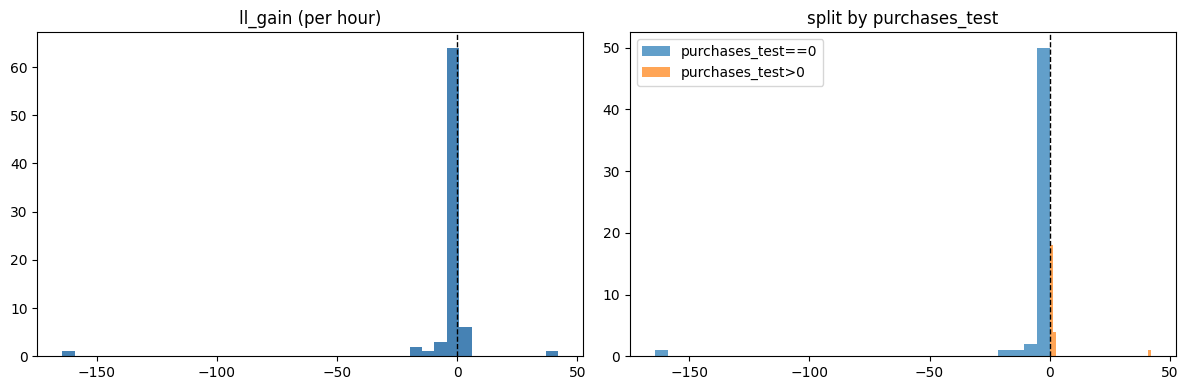

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(df['ll_gain'], bins=40, color='steelblue')
ax[0].axvline(0, color='black', linestyle='--', linewidth=1)
ax[0].set_title('ll_gain (per hour)')

if 'purchases_test' in df.columns:
    ax[1].hist(df[df['purchases_test']==0]['ll_gain'], bins=30, alpha=0.7, label='purchases_test==0')
    ax[1].hist(df[df['purchases_test']>0]['ll_gain'], bins=30, alpha=0.7, label='purchases_test>0')
    ax[1].axvline(0, color='black', linestyle='--', linewidth=1)
    ax[1].legend()
    ax[1].set_title('split by purchases_test')
else:
    ax[1].axis('off')

plt.tight_layout()
plt.show()


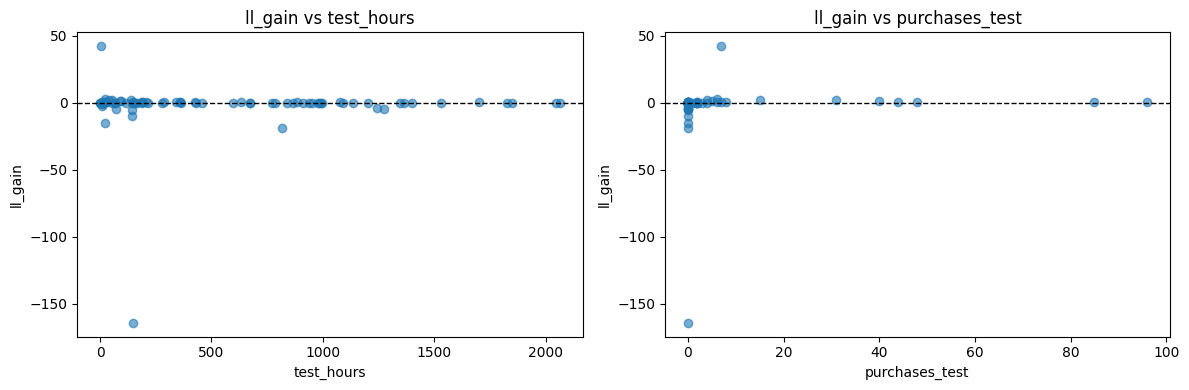

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
if 'test_hours' in df.columns:
    ax[0].scatter(df['test_hours'], df['ll_gain'], alpha=0.6)
    ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
    ax[0].set_xlabel('test_hours')
    ax[0].set_ylabel('ll_gain')
    ax[0].set_title('ll_gain vs test_hours')
else:
    ax[0].axis('off')

if 'purchases_test' in df.columns:
    ax[1].scatter(df['purchases_test'], df['ll_gain'], alpha=0.6)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=1)
    ax[1].set_xlabel('purchases_test')
    ax[1].set_ylabel('ll_gain')
    ax[1].set_title('ll_gain vs purchases_test')
else:
    ax[1].axis('off')

plt.tight_layout()
plt.show()


### alpha by type


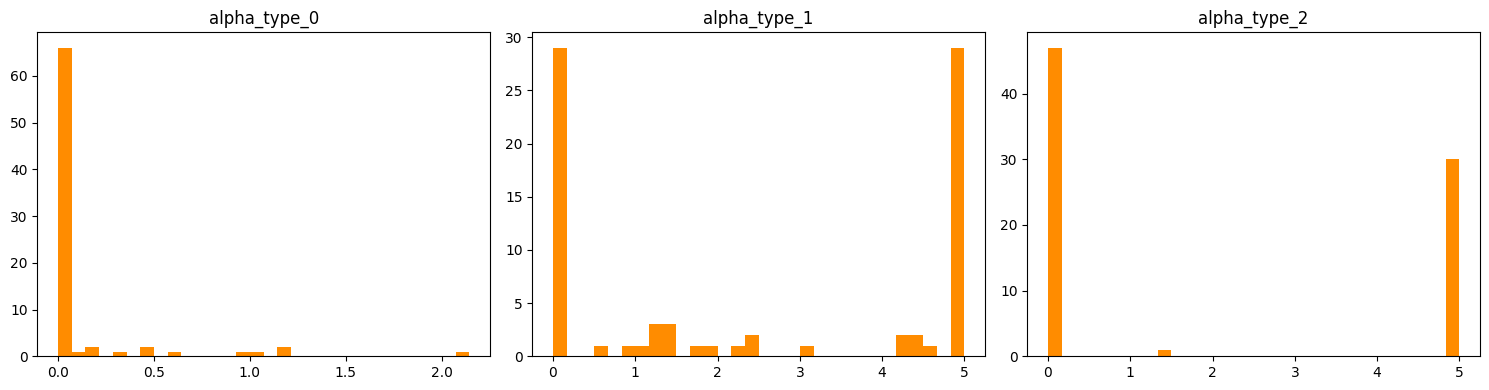

,mean,std,min,10%,50%,90%,95%,99%,max
alpha_type_0,0.115228,0.348350,0.0,0.0,0.000000,0.363267,0.959948,1.413464,2.144087
alpha_type_1,2.455424,2.267832,0.0,0.0,1.819191,5.000000,5.000000,5.000000,5.000000
alpha_type_2,1.940928,2.439061,0.0,0.0,0.000000,5.000000,5.000000,5.000000,5.000000


In [9]:
alpha_cols = [c for c in df.columns if c.startswith('alpha_type_')]
fig, ax = plt.subplots(1, len(alpha_cols), figsize=(5*len(alpha_cols),4))
if len(alpha_cols) == 1:
    ax = [ax]
for i, c in enumerate(alpha_cols):
    ax[i].hist(df[c], bins=30, color='darkorange')
    ax[i].set_title(c)
plt.tight_layout()
plt.show()

df[alpha_cols].describe(percentiles=[.1,.5,.9,.95,.99]).T[['mean','std','min','10%','50%','90%','95%','99%','max']]


### Best / worst sequences


In [10]:
cols = [c for c in ['seq_id','n_events','train_events','test_events','purchases_train','purchases_test','test_hours','ll_baseline','ll_hawkes','ll_gain'] if c in df.columns]
display(df.sort_values('ll_gain', ascending=False).head(10)[cols])
display(df.sort_values('ll_gain', ascending=True).head(10)[cols])


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_baseline,ll_hawkes,ll_gain
36,109357,101,79,22,12,7,3.676451,-44.321529,-2.247262,42.074267
68,175801,139,77,62,7,6,24.242313,-2.547435,0.193038,2.740473
6,22990,58,45,13,7,4,53.967943,-2.027058,0.067637,2.094695
23,57905,732,416,316,13,31,140.775903,-1.555335,0.134739,1.690073
4,17676,274,175,99,27,15,41.522170,-1.323814,0.249914,1.573728
22,55389,213,96,117,2,5,92.114777,-1.098205,0.020459,1.118664
77,198270,956,670,286,64,40,91.885906,-0.537046,0.314599,0.851645
54,152963,3024,2066,958,264,85,359.813392,-0.472749,0.191222,0.663971
29,76757,1883,1090,793,89,96,359.720951,-0.464047,0.130840,0.594887
59,163561,2410,1279,1131,48,44,288.445801,-0.398708,0.071033,0.469741


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_baseline,ll_hawkes,ll_gain
64,171718,203,185,18,33,0,148.752444,-0.254424,-164.609826,-164.355402
52,150651,71,54,17,8,0,818.940958,-0.004296,-18.791281,-18.786985
14,38103,25,23,2,7,0,24.519881,-1.178249,-16.654233,-15.475984
47,144274,22,20,2,2,0,142.210104,-0.018110,-9.954627,-9.936517
38,115257,70,61,9,5,0,143.828624,-0.015132,-5.920858,-5.905726
40,128147,25,23,2,2,0,72.646492,-0.033723,-4.636846,-4.603124
26,72254,22,21,1,2,0,1272.406069,-0.185989,-4.700275,-4.514286
8,24722,22,20,2,3,0,1244.356952,-0.098793,-4.151891,-4.053098
51,149854,24,23,1,4,0,7.849350,-0.806712,-3.277193,-2.470480
11,31645,53,51,2,3,0,11.674195,-0.037977,-1.381059,-1.343082


## Deep dive: one visitor timeline (optional)


In [11]:
from src.utils import temporal_train_test_split
from src.baselines import HourlySeasonalPoisson, ScaledBaseline
from src.hawkes import PurchaseTargetHawkes

EVENT_MAP = {'view': 0, 'addtocart': 1, 'transaction': 2}

def load_visitor_events(csv_path, visitor_id, chunksize=500_000):
    rows = []
    usecols = ['timestamp','visitorid','event']
    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        sub = chunk[chunk['visitorid'] == visitor_id]
        if not sub.empty:
            rows.append(sub)
    if not rows:
        return [], []
    dfv = pd.concat(rows, ignore_index=True)
    dfv = dfv[dfv['event'].isin(EVENT_MAP.keys())].copy()
    dfv['ts'] = pd.to_datetime(dfv['timestamp'], unit='ms')
    dfv = dfv.sort_values('ts')
    times = dfv['ts'].tolist()
    types = [EVENT_MAP[e] for e in dfv['event'].tolist()]
    return times, types

VISITOR_ID = int(df.sort_values('ll_gain', ascending=False).iloc[0]['seq_id'])
print('VISITOR_ID:', VISITOR_ID)


VISITOR_ID: 109357


In [12]:
if not HAS_DATA:
    raise FileNotFoundError(f'Missing data file: {DATA_PATH} (needed only for deep dive)')
times, types = load_visitor_events(DATA_PATH, VISITOR_ID)
print('events:', len(times))
if len(times) < 5:
    raise ValueError('Too few events for a meaningful plot')

train_ratio = 0.7
train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=train_ratio)

target_type = 2
purchases_train = [t for t,tp in zip(train_times, train_types) if tp == target_type]
purchases_test = [t for t,tp in zip(test_times, test_types) if tp == target_type]

base = HourlySeasonalPoisson().fit(purchases_train)
scaled = ScaledBaseline(base).fit(purchases_train, window_start=train_times[0], window_end=train_times[-1])
hawkes = PurchaseTargetHawkes(baseline=base, n_types=3, target_type=target_type).fit(train_times, train_types)

print('purchases_train:', len(purchases_train), 'purchases_test:', len(purchases_test))
print('scaled mu:', scaled.mu)
print('hawkes mu:', hawkes.params[0])
print('hawkes alphas:', hawkes.params[1:4])
print('hawkes betas :', hawkes.params[4:7])


events: 101
purchases_train: 12 purchases_test: 7
scaled mu: 1.6143693186343189
hawkes mu: 0.4183245205442699
hawkes alphas: [0.0, 0.0, 5.0]
hawkes betas : [3.739354203404802, 2.5622927085266234, 20.0]


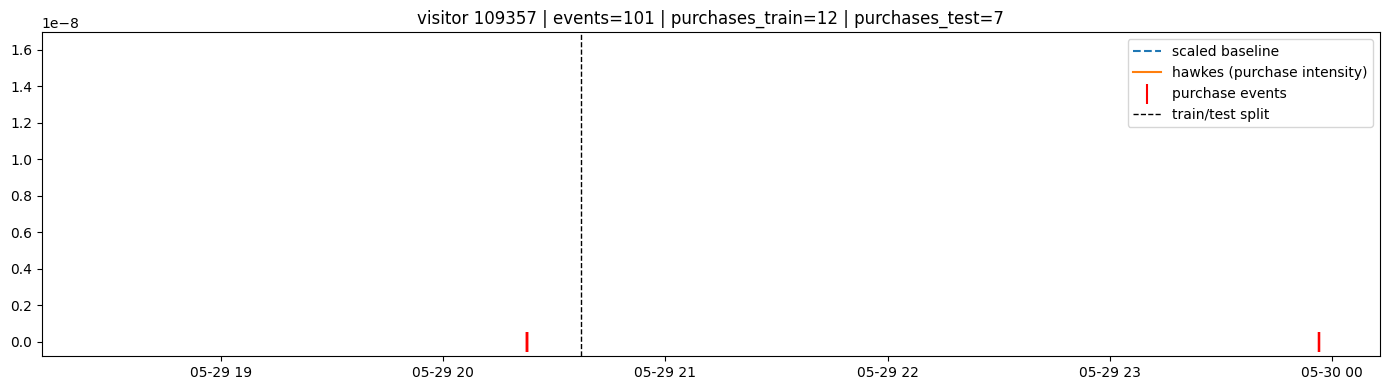

In [13]:
grid = pd.date_range(train_times[0], test_times[-1], freq='6h')
events = list(zip(times, types))
idx = 0
hist_t, hist_ty = [], []
lam_base, lam_hawk = [], []

for t in grid:
    while idx < len(events) and events[idx][0] <= t:
        hist_t.append(events[idx][0])
        hist_ty.append(events[idx][1])
        idx += 1
    lam_base.append(scaled.get_intensity(t))
    lam_hawk.append(hawkes.get_intensity(t, hist_t, hist_ty))

plt.figure(figsize=(14,4))
plt.plot(grid, lam_base, '--', label='scaled baseline')
plt.plot(grid, lam_hawk, label='hawkes (purchase intensity)')

# mark purchases
p_all = [t for t,tp in zip(times, types) if tp == target_type]
plt.scatter(p_all, [0]*len(p_all), marker='|', s=200, color='red', label='purchase events')

split_t = train_times[-1]
plt.axvline(split_t, color='black', linestyle='--', linewidth=1, label='train/test split')
plt.legend()
plt.title(f'visitor {VISITOR_ID} | events={len(times)} | purchases_train={len(purchases_train)} | purchases_test={len(purchases_test)}')
plt.tight_layout()
plt.show()
